<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [6]:
## Write your code here
#check shape
print('Dataset shape:', df.shape)
#check columns
print('\nDataset Types:')
print(df.dtypes)
#print info
print('\nDataset info')
print(df.info)

Dataset shape: (65437, 114)

Dataset Types:
ResponseId               int64
MainBranch              object
Age                     object
Employment              object
RemoteWork              object
                        ...   
JobSatPoints_11        float64
SurveyLength            object
SurveyEase              object
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object

Dataset info
<bound method DataFrame.info of        ResponseId                      MainBranch                 Age  \
0               1  I am a developer by profession  Under 18 years old   
1               2  I am a developer by profession     35-44 years old   
2               3  I am a developer by profession     45-54 years old   
3               4           I am learning to code     18-24 years old   
4               5  I am a developer by profession     18-24 years old   
...           ...                             ...                 ...   
65432       65433  I am a devel

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [10]:
## Write your code here
#Identify missing values
missing_value= df.isnull().sum().sort_values(ascending=False)
missing_value

#Impute missing value for RemoteWork, JobSat
print('RemoteWork missing value before impute:', df['RemoteWork'].isnull().sum())
print('JobSat missing value before impute:', df['JobSat'].isnull().sum())

df['RemoteWork']=df['RemoteWork'].fillna(df['RemoteWork'].mode()[0])
df['JobSat']= df['JobSat'].fillna(df['JobSat'].median())

print('RemoteWork missing value after impute:', df['RemoteWork'].isnull().sum())
print('JobSat missing value after impute:', df['JobSat'].isnull().sum())

RemoteWork missing value before impute: 10631
JobSat missing value before impute: 36311
RemoteWork missing value after impute: 0
JobSat missing value after impute: 0


### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [24]:
## Write your code here
columns= ['Employment','JobSat','YearsCodePro']

for col in columns:
    print(f'\nDistribution for {col}')
    print(df[col].value_counts(dropna=False))


Distribution for Employment
Employment
Employed, full-time                                                                                                                                  39041
Independent contractor, freelancer, or self-employed                                                                                                  4846
Student, full-time                                                                                                                                    4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                              3557
Not employed, but looking for work                                                                                                                    2341
                                                                                                                                                     ...  
Employed, full-time;Student, f

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


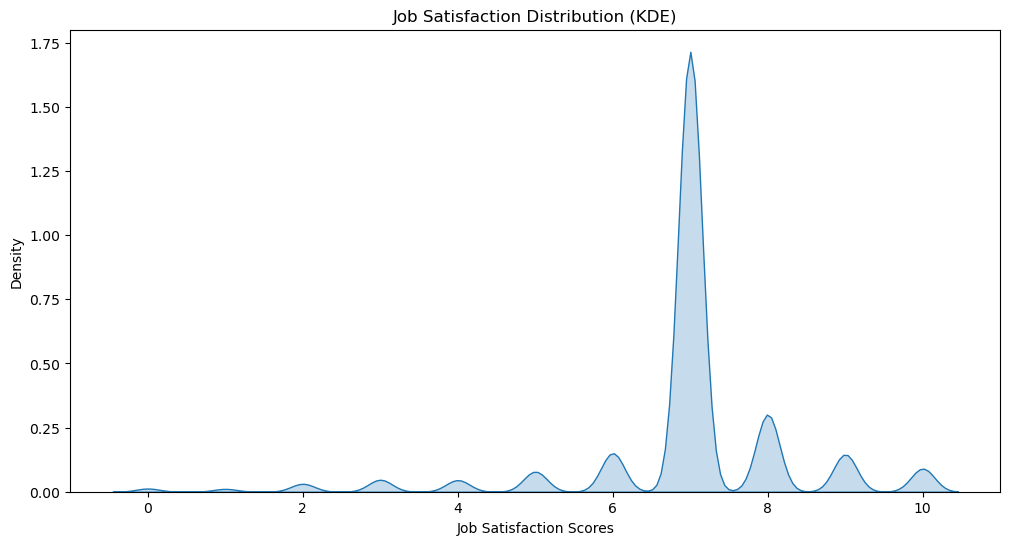

In [28]:
## Write your code here
#Use KDE
JobSat_value_counts= df['JobSat'].value_counts()

plt.figure(figsize=(12,6))

sns.kdeplot(df['JobSat'], fill=True)

plt.title('Job Satisfaction Distribution (KDE)')
plt.xlabel('Job Satisfaction Scores')
plt.show()

From the KDE plot, it was observed that most respondents report moderate to high level of job satisfaction. Majority respondent (1.75 ) have score 7 on their job satisfaction, indicates that most of the respondent are generally satisfy with their job.

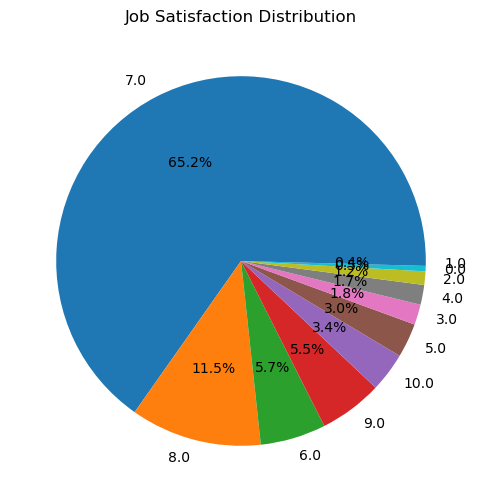

In [29]:
#Use pie
plt.figure(figsize=(12,6))

JobSat_val_counts= df['JobSat'].value_counts()
plt.pie(JobSat_val_counts, labels=JobSat_val_counts.index, autopct='%1.1f%%')

plt.title('Job Satisfaction Distribution')
plt.show()

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


In [33]:
## Write your code here
#split
lang_worked = df['LanguageHaveWorkedWith'].str.split(';').explode()
lang_want= df['LanguageWantToWorkWith'].str.split(';').explode()

#value counts
worked_count= lang_worked.value_counts()
want_count= lang_want.value_counts()

#print
print(worked_count.head(10))
print(want_count.head(10))

LanguageHaveWorkedWith
JavaScript                 37492
HTML/CSS                   31816
Python                     30719
SQL                        30682
TypeScript                 23150
Bash/Shell (all shells)    20412
Java                       18239
C#                         16318
C++                        13827
C                          12184
Name: count, dtype: int64
LanguageWantToWorkWith
Python                     25047
JavaScript                 23774
SQL                        22400
HTML/CSS                   20721
TypeScript                 20239
Rust                       17232
Go                         13837
Bash/Shell (all shells)    13744
C#                         12921
C++                        10873
Name: count, dtype: int64


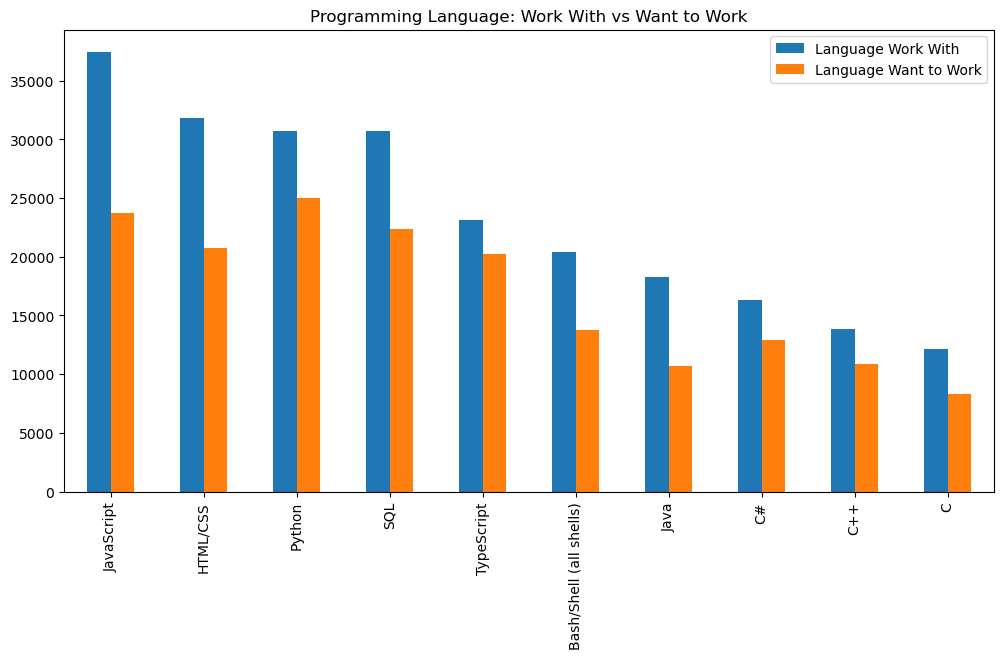

In [35]:
#visualization
language_df= pd.DataFrame({'Language Work With': worked_count, 'Language Want to Work': want_count}).fillna(0)

top_language= language_df.sort_values('Language Work With', ascending=False).head(10)

top_language.plot(kind='bar', figsize=(12,6))

plt.title('Programming Language: Work With vs Want to Work')
plt.show()

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


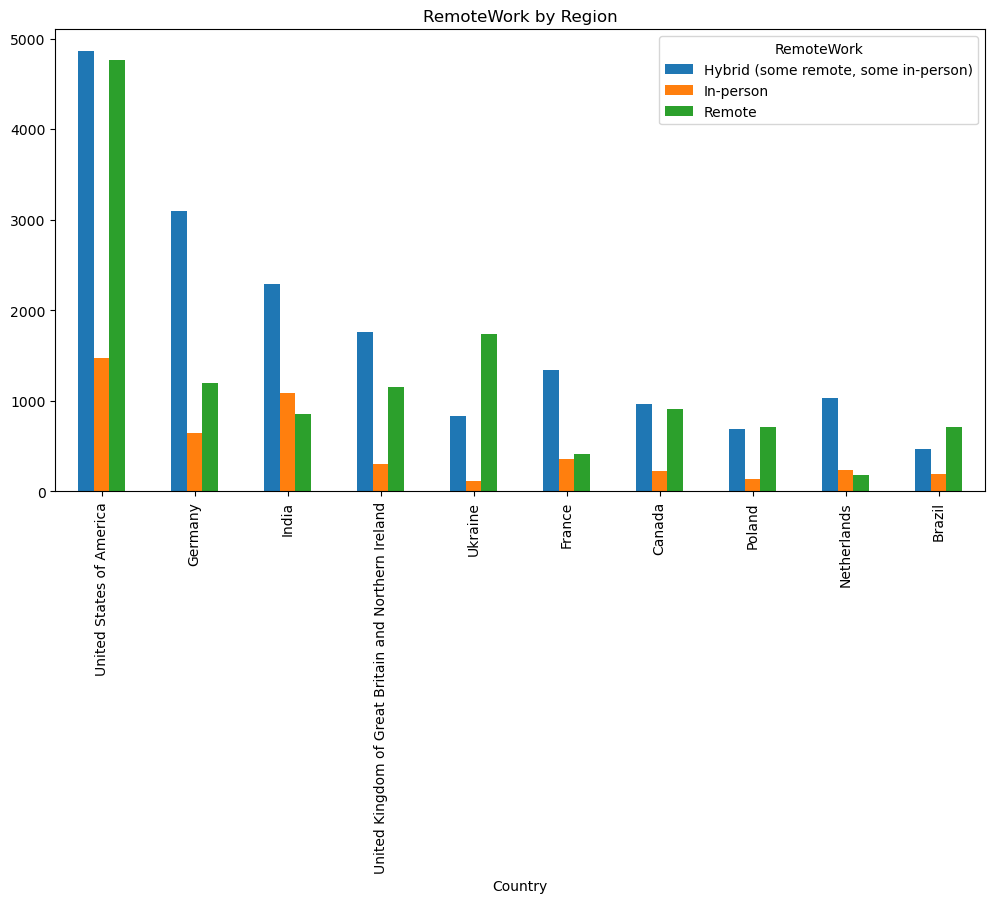

In [61]:
## Write your code here
#Create dataset
remote_region = pd.crosstab(df['Country'],df['RemoteWork'])
#Add a sum column
remote_region['Total']= remote_region.sum(axis=1)
#sorted by total number of remote work, descending order
top_country=remote_region.sort_values(by= 'Total', ascending=False).head(10)
#remove total column
top_country=top_country.drop(columns='Total')
#plot
top_country.plot(kind='bar', figsize=(12,6))

plt.title('RemoteWork by Region')

plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


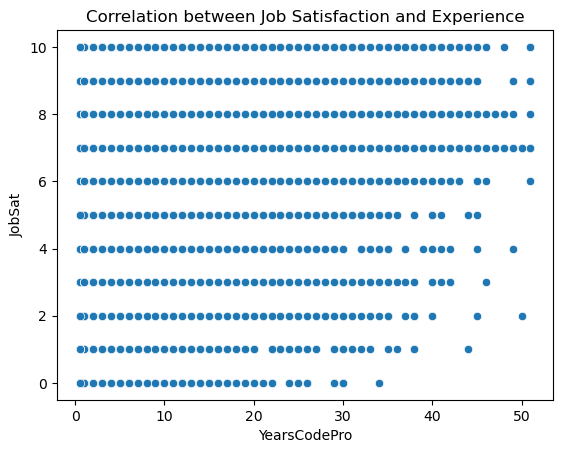

In [73]:
## Write your code here
df['YearsCodePro']= df['YearsCodePro'].replace({'Less than 1 year':0.5, 'More than 50 years':51})
#set to numerical value
df['YearsCodePro']= pd.to_numeric(df['YearsCodePro'])
#Visualize
sns.scatterplot(y='JobSat', x='YearsCodePro', data= df)
plt.title('Correlation between Job Satisfaction and Experience')

plt.show()

In [75]:
#Pearson correlation
corr= df[['YearsCodePro','JobSat']].corr(method='pearson')
print(corr)

              YearsCodePro    JobSat
YearsCodePro      1.000000  0.071994
JobSat            0.071994  1.000000


### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


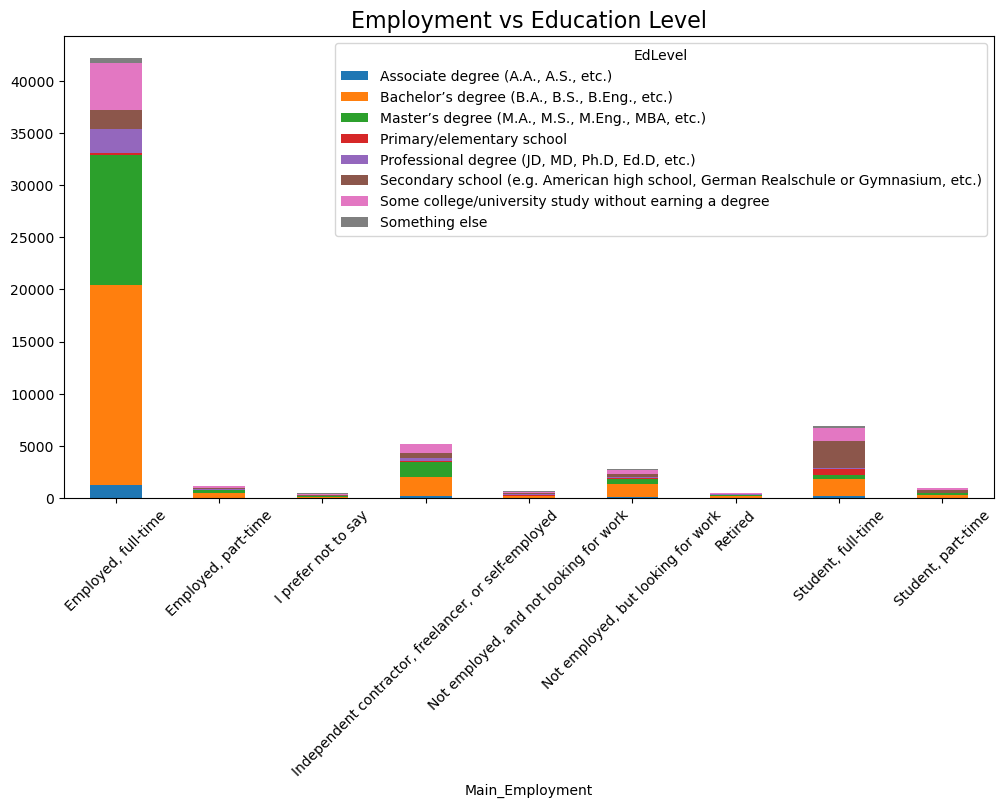

In [82]:
## Write your code here
df['Main_Employment']= df['Employment'].str.split(';').str[0]
cross_tab= pd.crosstab(df['Main_Employment'], df['EdLevel'])
cross_tab.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Employment vs Education Level', fontsize=16)
plt.xticks(rotation=45)
plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [83]:
## Write your code here
df.to_csv('Cleaned_Dataset.csv', index=False)
print('saved successfully')

saved successfully


### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
